In [1]:
import glob
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

from sklearn.impute import SimpleImputer

In [17]:
cell_prop_largeG_u25 = pd.read_csv("./Fig.S2.value.tsv", sep="\t", index_col=0)
cell_prop_largeG_u25.columns = [
    _.split("_")[0] for _ in cell_prop_largeG_u25.columns
]

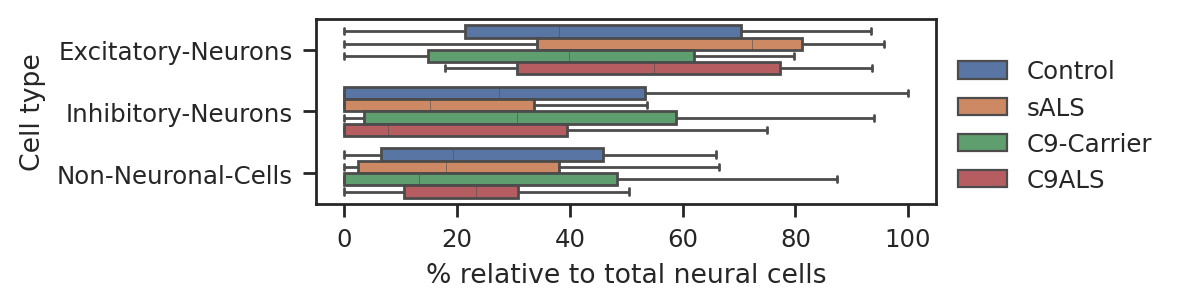

In [18]:

cell_prop_largeG_u25 = cell_prop_largeG_u25.loc[
    [
        "Excitatory-Neurons",
        "Inhibitory-Neurons",
        "Non-Neuronal-Cells",
    ]
]

cell_prop_largeG_u25_sum = cell_prop_largeG_u25.sum(axis=0)



cell_prop_largeG_u25_relative = 100 * (
    cell_prop_largeG_u25 / cell_prop_largeG_u25_sum
)
cell_prop_largeG_u25_relative = (
    cell_prop_largeG_u25_relative.loc[
        [
            "Excitatory-Neurons",
            "Inhibitory-Neurons",
            "Non-Neuronal-Cells",
        ]
    ]
    .melt(ignore_index=False, var_name="Group", value_name="Ratio")
    .reset_index()
    .replace("C9-Patient", "C9ALS")
    .replace("Blood immune", "Blood-immune")
    .rename(columns={"index": "Tissue"})
)


f, ax = plt.subplots(figsize=(4, 1.2))
sns.set_theme("paper", style="ticks")
sns.boxplot(
    data=cell_prop_largeG_u25_relative[
        cell_prop_largeG_u25_relative["Tissue"].isin(
        [
        "Excitatory-Neurons",
        "Non-Neuronal-Cells",
        "Inhibitory-Neurons",
        ]
        )
    ],
    y="Tissue",
    x="Ratio",
    hue="Group",medianprops={"linewidth": 0.2}
)

ax.set(ylabel="Cell type", xlabel="% relative to total neural cells")
ax.legend(
    frameon=False, markerscale=0.4, ncols=1, bbox_to_anchor=(1, 0.9)
)  # loc='best',

ax.figure.savefig(
    "./Fig.S2.png",
    bbox_inches="tight",
    dpi=600,
)